# Apple Quality

In [1]:
import pandas as pd
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

In [2]:
df = pd.read_csv("apple_quality.csv")
df.head()

,A_id,Size,Weight,Sweetness,Crunchiness,Juiciness,Ripeness,Acidity,Quality
0,0.0,-3.970049,-2.512336,5.346330,-1.012009,1.844900,0.329840,-0.491590483,good
1,1.0,-1.195217,-2.839257,3.664059,1.588232,0.853286,0.867530,-0.722809367,good
2,2.0,-0.292024,-1.351282,-1.738429,-0.342616,2.838636,-0.038033,2.621636473,bad
3,3.0,-0.657196,-2.271627,1.324874,-0.097875,3.637970,-3.413761,0.790723217,good
4,4.0,1.364217,-1.296612,-0.384658,-0.553006,3.030874,-1.303849,0.501984036,good


In [3]:
print("Shape:", df.shape)
df.info()

Shape: (4001, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4001 entries, 0 to 4000
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   A_id         4000 non-null   float64
 1   Size         4000 non-null   float64
 2   Weight       4000 non-null   float64
 3   Sweetness    4000 non-null   float64
 4   Crunchiness  4000 non-null   float64
 5   Juiciness    4000 non-null   float64
 6   Ripeness     4000 non-null   float64
 7   Acidity      4001 non-null   object 
 8   Quality      4000 non-null   object 
dtypes: float64(7), object(2)
memory usage: 281.4+ KB


In [4]:
# The last row is a junk footer ("Created_by_Nidula_Elgiriyewithana") and has no real data.
df.tail()

,A_id,Size,Weight,Sweetness,Crunchiness,Juiciness,Ripeness,Acidity,Quality
3996,3996.0,-0.293118,1.949253,-0.204020,-0.640196,0.024523,-1.087900,1.854235285,good
3997,3997.0,-2.634515,-2.138247,-2.440461,0.657223,2.199709,4.763859,-1.334611391,bad
3998,3998.0,-4.008004,-1.779337,2.366397,-0.200329,2.161435,0.214488,-2.229719806,good
3999,3999.0,0.278540,-1.715505,0.121217,-1.154075,1.266677,-0.776571,1.599796456,good
4000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Created_by_Nidula_Elgiriyewithana,NaN


In [5]:
# Drop the trailing footer row and the unneeded id column
df = df.dropna().reset_index(drop=True)
df = df.drop(columns=["A_id"])

# Acidity was read as text because of the footer row -> convert to numeric
df["Acidity"] = pd.to_numeric(df["Acidity"])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Size         4000 non-null   float64
 1   Weight       4000 non-null   float64
 2   Sweetness    4000 non-null   float64
 3   Crunchiness  4000 non-null   float64
 4   Juiciness    4000 non-null   float64
 5   Ripeness     4000 non-null   float64
 6   Acidity      4000 non-null   float64
 7   Quality      4000 non-null   object 
dtypes: float64(7), object(1)
memory usage: 250.1+ KB


In [6]:
# Data quality checks
print("Missing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("\nQuality classes:\n", df["Quality"].value_counts())

Missing values:
 Size           0
Weight         0
Sweetness      0
Crunchiness    0
Juiciness      0
Ripeness       0
Acidity        0
Quality        0
dtype: int64

Duplicate rows: 0

Quality classes:
 Quality
good    2004
bad     1996
Name: count, dtype: int64


In [9]:
df.describe()

,Size,Weight,Sweetness,Crunchiness,Juiciness,Ripeness,Acidity
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,-0.503015,-0.989547,-0.470479,0.985478,0.512118,0.498277,0.076877
std,1.928059,1.602507,1.943441,1.402757,1.930286,1.874427,2.110270
min,-7.151703,-7.149848,-6.894485,-6.055058,-5.961897,-5.864599,-7.010538
25%,-1.816765,-2.011770,-1.738425,0.062764,-0.801286,-0.771677,-1.377424
50%,-0.513703,-0.984736,-0.504758,0.998249,0.534219,0.503445,0.022609
75%,0.805526,0.030976,0.801922,1.894234,1.835976,1.766212,1.510493
max,6.406367,5.790714,6.374916,7.619852,7.364403,7.237837,7.404736


In [10]:
# Допрос одной колонки: Ripeness
r = df["Ripeness"]

print(f"mean   = {r.mean():.4f}")
print(f"median = {r.median():.4f}")
print(f"std    = {r.std():.4f}")
print(f"min    = {r.min():.4f}")
print(f"Q1     = {r.quantile(0.25):.4f}")
print(f"Q3     = {r.quantile(0.75):.4f}")
print(f"max    = {r.max():.4f}")
print(f"IQR    = {r.quantile(0.75) - r.quantile(0.25):.4f}")
print(f"skew   = {r.skew():.4f}")

mean   = 0.4983
median = 0.5034
std    = 1.8744
min    = -5.8646
Q1     = -0.7717
Q3     = 1.7662
max    = 7.2378
IQR    = 2.5379
skew   = -0.0088


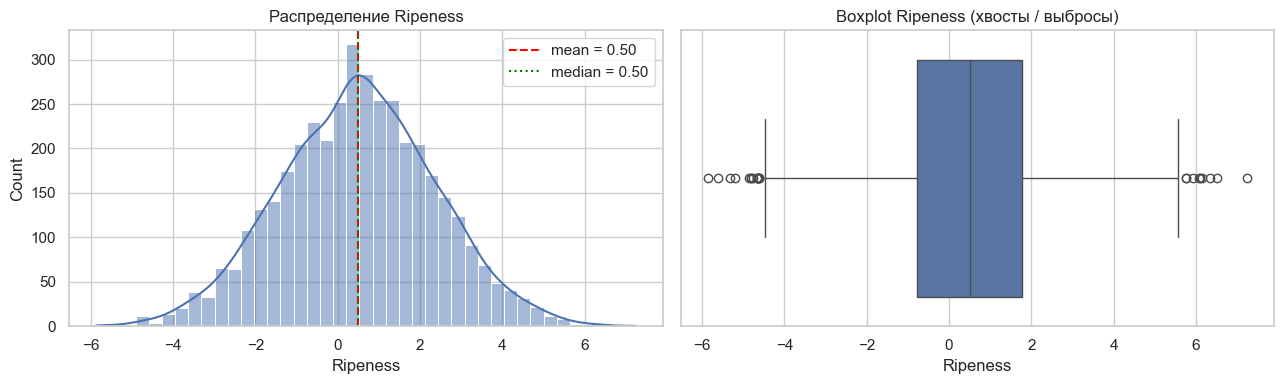

In [11]:
# Визуальная проверка распределения Ripeness
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.histplot(df["Ripeness"], kde=True, ax=axes[0])
axes[0].axvline(r.mean(), color="red", linestyle="--", label=f"mean = {r.mean():.2f}")
axes[0].axvline(r.median(), color="green", linestyle=":", label=f"median = {r.median():.2f}")
axes[0].set_title("Распределение Ripeness")
axes[0].legend()

sns.boxplot(x=df["Ripeness"], ax=axes[1])
axes[1].set_title("Boxplot Ripeness (хвосты / выбросы)")

plt.tight_layout()
plt.show()

In [12]:
# Допрос одной колонки: Sweetness
s = df["Sweetness"]

print(f"mean   = {s.mean():.4f}")
print(f"median = {s.median():.4f}")
print(f"std    = {s.std():.4f}")
print(f"min    = {s.min():.4f}")
print(f"Q1     = {s.quantile(0.25):.4f}")
print(f"Q3     = {s.quantile(0.75):.4f}")
print(f"max    = {s.max():.4f}")
print(f"IQR    = {s.quantile(0.75) - s.quantile(0.25):.4f}")
print(f"skew   = {s.skew():.4f}")

mean   = -0.4705
median = -0.5048
std    = 1.9434
min    = -6.8945
Q1     = -1.7384
Q3     = 0.8019
max    = 6.3749
IQR    = 2.5403
skew   = 0.0838


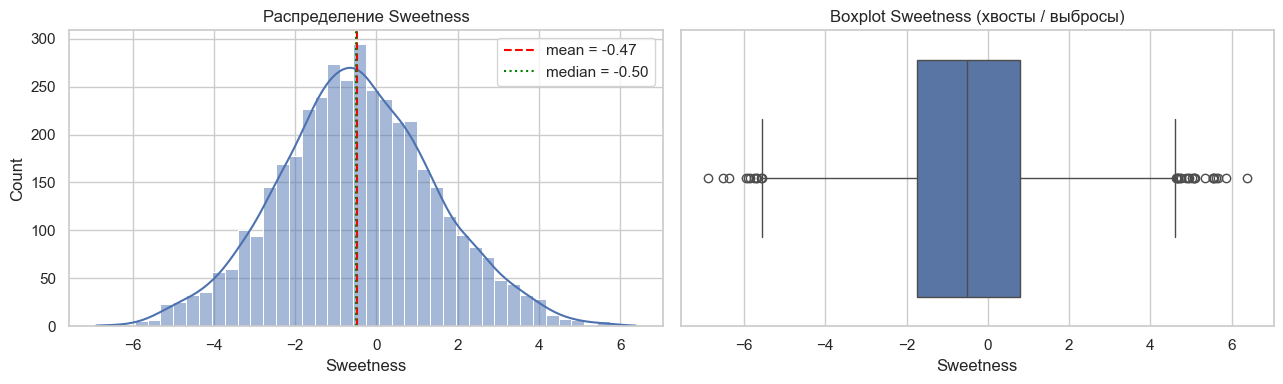

In [13]:
# Визуальная проверка распределения Sweetness
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.histplot(df["Sweetness"], kde=True, ax=axes[0])
axes[0].axvline(s.mean(), color="red", linestyle="--", label=f"mean = {s.mean():.2f}")
axes[0].axvline(s.median(), color="green", linestyle=":", label=f"median = {s.median():.2f}")
axes[0].set_title("Распределение Sweetness")
axes[0].legend()

sns.boxplot(x=df["Sweetness"], ax=axes[1])
axes[1].set_title("Boxplot Sweetness (хвосты / выбросы)")

plt.tight_layout()
plt.show()

In [14]:
# Проблемный столбец: Weight (больше всего выбросов, тяжёлые хвосты, не центрирован у 0)
w = df["Weight"]

print(f"mean   = {w.mean():.4f}")
print(f"median = {w.median():.4f}")
print(f"std    = {w.std():.4f}")
print(f"min    = {w.min():.4f}")
print(f"Q1     = {w.quantile(0.25):.4f}")
print(f"Q3     = {w.quantile(0.75):.4f}")
print(f"max    = {w.max():.4f}")
print(f"IQR    = {w.quantile(0.75) - w.quantile(0.25):.4f}")
print(f"skew   = {w.skew():.4f}")
print(f"kurt   = {w.kurt():.4f}")

# выбросы по правилу 1.5*IQR
q1, q3 = w.quantile(0.25), w.quantile(0.75)
iqr = q3 - q1
lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
out = w[(w < lo) | (w > hi)]
print(f"\nграницы усов: [{lo:.2f}, {hi:.2f}]")
print(f"выбросов: {len(out)} ({len(out) / len(w) * 100:.2f}%)")

mean   = -0.9895
median = -0.9847
std    = 1.6025
min    = -7.1498
Q1     = -2.0118
Q3     = 0.0310
max    = 5.7907
IQR    = 2.0427
skew   = 0.0031
kurt   = 0.3590

границы усов: [-5.08, 3.10]
выбросов: 54 (1.35%)


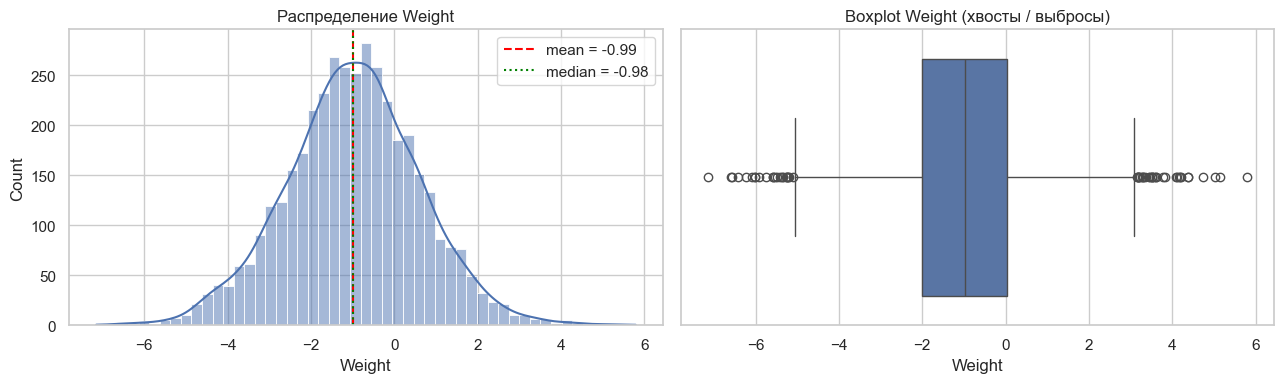

In [15]:
# Визуальная проверка распределения Weight
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.histplot(df["Weight"], kde=True, ax=axes[0])
axes[0].axvline(w.mean(), color="red", linestyle="--", label=f"mean = {w.mean():.2f}")
axes[0].axvline(w.median(), color="green", linestyle=":", label=f"median = {w.median():.2f}")
axes[0].set_title("Распределение Weight")
axes[0].legend()

sns.boxplot(x=df["Weight"], ax=axes[1])
axes[1].set_title("Boxplot Weight (хвосты / выбросы)")

plt.tight_layout()
plt.show()